<a href="https://colab.research.google.com/github/Cosio1985/proyecto-mineria-datos/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Investigación sobre la Predicción de Efectividad de Tiros en la NBA (Kobe Bryant)
**Curso:** Minería de Datos | **Nivel:** Maestría en Ciencias de la Computación  
**Enfoque:** Ciencia 2.0 (Reproducible y de Código Abierto)  
**Autor:** José Alfredo Martínez Cosío  

---

## 1. Definición del Problema
En el ámbito del análisis deportivo moderno (*Sports Analytics*), la evaluación del rendimiento y la toma de decisiones basada en datos se ha convertido en un pilar fundamental para las organizaciones de alta competencia (Alamar, 2013). El éxito de un equipo de baloncesto depende críticamente de la eficiencia de sus posesiones y, de manera más específica, de la selección inteligente de los tiros de campo por los jugadores.

Este proyecto aborda el problema de modelar una tarea de **clasificación binaria supervisada**. El objetivo primordial es predecir si un intento de tiro por parte del jugador histórico Kobe Bryant será anotado (`1`) o fallado (`0`). El modelo matemático se expresa como:

$$f(X) = Y \in \{0, 1\}$$

Donde $X$ representa un vector de características cuantitativas y cualitativas que describen el contexto geométrico y temporal en el instante exacto en que se ejecuta el tiro. Dominar esta predicción permite mapear patrones de rendimiento y entender los factores que maximizan o penalizan la probabilidad de encestar.

## 2. Contexto General y Revisión de Literatura
La literatura científica dedicada al baloncesto demuestra que la efectividad en el tiro de campo no es un evento puramente estocástico o de azar; está fuertemente condicionada por dinámicas espacio-temporales medibles (Shea, 2014). Al revisar investigaciones previas en minería de datos aplicada al deporte, se identifican tres componentes críticos:

1. **Variables Geométricas y Espaciales:** La distancia euclidiana respecto al centro del aro es el predictor más intuitivo y penalizador. Conforme un jugador se aleja de la canasta, el ángulo de tiro y la fuerza requerida cambian, alterando drásticamente la probabilidad de éxito. Asimismo, la posición angular en la cancha (coordenadas X , Y) discrimina las zonas de confort o "puntos calientes" del atleta.
2. **Factores Temporales y de Presión:** El tiempo restante en el reloj de tiro y el período del partido introducen variables psicológicas y físicas como la fatiga acumulada y la toma de decisiones bajo estrés de último segundo.
3. **Complejidad del Algoritmo vs Interpretabilidad:** Investigaciones en aprendizaje computacional sugieren que aunque los modelos lineales (Regresión Logística) ofrecen una excelente interpretabilidad analítica de los pesos de las variables, los modelos basados en árboles (Random Forest) y fronteras de decisión complejas (SVM) logran capturar interacciones no lineales que los humanos omiten a simple vista (Pedregosa et al., 2011).

Para este estudio, la información y el conjunto de datos históricos se obtienen de los registros oficiales analizados en la comunidad científica de Kaggle (Kaggle, 2016), permitiendo evaluar el problema bajo un flujo riguroso, auditable y transparente.

In [1]:
# APLICAR CONFIGURACIONES Y CARGAR DATOS DEL DATASET DE KAGGLE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# La semilla global la ponemos en 42 para que sea considerada como una reproducción cientifica.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configuración de estilos visuales
# Los gráficos tendrán un fondo blanco y cuadricula gris
sns.set_theme(style="whitegrid")

# Establecemos el ancho a 10 pulgadas y el alto a 6 pulgadas, lo que define las dimensiones de los plots.
plt.rcParams['figure.figsize'] = (10, 6)


## 3. Obtención de Datos
Para garantizar la transparencia científica, utilizamos el conjunto de datos público de Kaggle: *Kobe Bryant Shot Selection*. Los datos han sido alojados de forma abierta en nuestro repositorio de GitHub para permitir que cualquier investigador replique este experimento con un solo clic, sin necesidad de autenticaciones locales.

In [2]:
# Ruta donde esta el dataset kobe_data en Github
URL_DATASET = "https://raw.githubusercontent.com/Cosio1985/proyecto-mineria-datos/refs/heads/main/data/kobe_data.csv"

try:
    # Cargamos los datos del repo
    df_raw = pd.read_csv(URL_DATASET)
    print(f"Dataset cargado directamente desde GitHub.")
    print(f"Dimensiones iniciales: {df_raw.shape}")
except Exception as e:
    print("Error al cargar desde la URL. Asegúrate de que el repositorio sea público o verifica la URL.")
    print("Detalle del error:", e)

Dataset cargado directamente desde GitHub.
Dimensiones iniciales: (30697, 25)


## 4. Preprocesamiento de los Datos, Limpieza e Inspección
El conjunto de datos original cuenta con instancias vacías en la variable objetivo (destinadas a la evaluación en Kaggle). Como parte de la limpieza, se eliminan estas filas para trabajar exclusivamente con datos reales etiquetados. Procedemos a realizar la inspección estadística elemental requerida.

In [3]:
# EN ESTA SECCIÓN DEBEMOS HACER UNA LIMPIEZA INICIAL DE DATOS

# Filtrar el dataset para quedarnos solo con los tiros que tienen etiqueta (0 o 1)
df_tiros = df_raw.dropna(subset=['shot_made_flag']).copy()

# Convertir la variable objetivo a tipo entero para los modelos
df_tiros['shot_made_flag'] = df_tiros['shot_made_flag'].astype(int)

print(f"Instancias disponibles para entrenamiento/prueba: {df_tiros.shape[0]}")
print(f"Variables analizadas: {df_tiros.shape[1]}")

Instancias disponibles para entrenamiento/prueba: 25697
Variables analizadas: 25


In [4]:
# EXPLORACIÓN ESTADÍSTICA


print("--- Primeras 5 filas del Dataset Real ---")
print(df_tiros[['loc_x', 'loc_y', 'shot_distance', 'period', 'seconds_remaining', 'shot_made_flag']].head())

print("\n--- Resumen Estadístico de las Variables Numéricas ---")
print(df_tiros[['loc_x', 'loc_y', 'shot_distance', 'seconds_remaining']].describe())

--- Primeras 5 filas del Dataset Real ---
   loc_x  loc_y  shot_distance  period  seconds_remaining  shot_made_flag
1   -157      0             15       1                 22               0
2   -101    135             16       1                 45               1
3    138    175             22       1                 52               0
4      0      0              0       2                 19               1
5   -145    -11             14       3                 32               0

--- Resumen Estadístico de las Variables Numéricas ---
              loc_x         loc_y  shot_distance  seconds_remaining
count  25697.000000  25697.000000   25697.000000       25697.000000
mean       7.148422     91.257345      13.457096          28.311554
std      110.073147     88.152106       9.388725          17.523392
min     -250.000000    -44.000000       0.000000           0.000000
25%      -67.000000      4.000000       5.000000          13.000000
50%        0.000000     74.000000      15.000000  

### Análisis Exploratorio Visual
Para comprender la distribución geoespacial de los tiros anotados y fallados, se proyectan las coordenadas cartesianas (`loc_x`, `loc_y`) emulando las dimensiones físicas de la cancha de baloncesto.


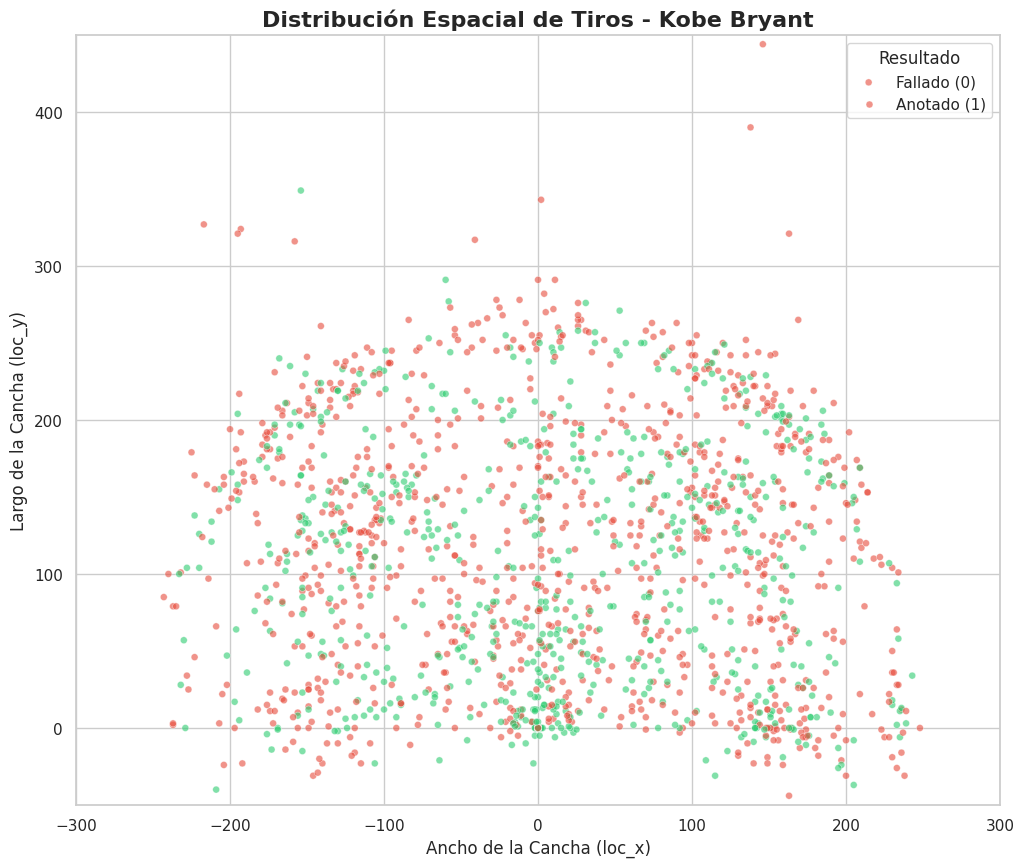

In [5]:
# VISUALIZACIÓN: DISTRIBUCIÓN ESPACIAL DE LOS TIROS

plt.figure(figsize=(12, 10))

# Tomamos una muestra aleatoria de 2,000 tiros para no saturar la gráfica visualmente
df_muestra = df_tiros.sample(n=2000, random_state=RANDOM_STATE)

# Graficar los tiros fallados (0) y anotados (1)
sns.scatterplot(
    data=df_muestra,
    x='loc_x',
    y='loc_y',
    hue='shot_made_flag',
    palette={0: '#e74c3c', 1: '#2ecc71'}, # Rojo para fallado, Verde para anotado
    alpha=0.6,
    s=25
)

plt.title('Distribución Espacial de Tiros - Kobe Bryant', fontsize=16, fontweight='bold')
plt.xlabel('Ancho de la Cancha (loc_x)', fontsize=12)
plt.ylabel('Largo de la Cancha (loc_y)', fontsize=12)
plt.legend(title='Resultado', labels=['Fallado (0)', 'Anotado (1)'])
plt.gca().set_aspect('equal', adjustable='box') # Mantiene la proporción real de la cancha
plt.xlim(-300, 300)
plt.ylim(-50, 450)
plt.show()

### Ingeniería de Características y Transformación
Los modelos de aprendizaje supervisado requieren entradas puramente numéricas. Por lo tanto, aplicamos *One-Hot Encoding* a las variables de tipo de tiro (`shot_type` y `combined_shot_type`) para vectorizarlas correctamente.

In [6]:
# PREPROCESAMIENTO: SELECCIÓN DE CARACTERÍSTICAS Y CODIFICACIÓN

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Debemos seleccionar un conjunto de características relevantes
variables_num = ['shot_distance', 'period', 'seconds_remaining']
variables_cat = ['shot_type', 'combined_shot_type']

# Crear el DataFrame de características (X) y la variable objetivo (y)
X = df_tiros[variables_num + variables_cat].copy()
y = df_tiros['shot_made_flag'].copy()

# Codificación de variables categóricas
X = pd.get_dummies(X, columns=variables_cat, drop_first=True, dtype=int)

print(f"Estructura de la matriz de características X después del One-Hot Encoding: {X.shape}")
print("Variables finales listas para el modelo:\n", X.columns.tolist())

Estructura de la matriz de características X después del One-Hot Encoding: (25697, 9)
Variables finales listas para el modelo:
 ['shot_distance', 'period', 'seconds_remaining', 'shot_type_3PT Field Goal', 'combined_shot_type_Dunk', 'combined_shot_type_Hook Shot', 'combined_shot_type_Jump Shot', 'combined_shot_type_Layup', 'combined_shot_type_Tip Shot']


## 5. Preparación de los Datos: División y Escalado
Para poder evaluar nuestros modelos de Inteligencia Artificial de forma justa, el diseño experimental se rige bajo dos pasos esenciales:
1. **División de Datos:** Separamos la muestra en un 80% para el entrenamiento de los algoritmos y un 20% que reservaremos exclusivamente para ponerlos a prueba. Es importante asegurarnos de que ambos conjuntos tengan el mismo porcentaje de tiros anotados y fallados.
2. **Escalado de Variables:** Modelos como la Regresión Logística y SVM son muy sensibles a los rangos numéricos. Si dejamos los segundos restantes (números grandes hasta 720) mezclados con la distancia (números pequeños), el modelo se confundiría. El escalador (`StandardScaler`) ajusta todo para que las variables tengan el mismo peso matemático.

In [7]:

# DIVISIÓN DE DATOS Y ESCALADO PUNTOS IMPORTANTES PARA LA REPRODUCIBILIDAD

# División balanceada garantizada por la semilla RANDOM_STATE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Inicializar el escalador
scaler = StandardScaler()

# Ajustar con los datos de entrenamiento y transformar ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Conjunto de Entrenamiento: {X_train_scaled.shape[0]} muestras")
print(f"Conjunto de Prueba: {X_test_scaled.shape[0]} muestras")

Conjunto de Entrenamiento: 20557 muestras
Conjunto de Prueba: 5140 muestras


## 6. Diseño de Experimentos: Entrenamiento de Modelos
En esta fase central de la investigación, ponemos a competir tres arquitecturas de aprendizaje supervisado con enfoques teóricos muy distintos para descubrir cuál predice mejor el éxito de los tiros:
- **Regresión Logística:** Un modelo lineal tradicional que nos ayuda a entender fácilmente cómo afecta cada variable de forma directa.
- **Random Forest (Bosque Aleatorio):** Un modelo basado en múltiples árboles de decisión que calcula combinaciones no lineales complejas (por ejemplo, el efecto del tiempo cuando se está lejos del aro).
- **Support Vector Machine (SVM):** Un modelo avanzado que busca crear fronteras geométricas óptimas en espacios de múltiples dimensiones para separar los tiros anotados de los fallados.

In [8]:
# DISEÑO DE EXPERIMENTOS: ENTRENAMIENTO DE MODELOS

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Inicializamos los tres modelos con la misma semilla
modelos = {
    "Regresión Logística": LogisticRegression(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100, max_depth=10),
    "Support Vector Machine (SVM)": SVC(random_state=RANDOM_STATE, probability=True)
}

# Este es el diccionario para almacenar las predicciones
predicciones = {}

# Entrenar cada modelo y predecir
for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")
    modelo.fit(X_train_scaled, y_train)
    predicciones[nombre] = modelo.predict(X_test_scaled)
print("\n¡Todos los modelos han sido entrenados con éxito!")

Entrenando Regresión Logística...
Entrenando Random Forest...
Entrenando Support Vector Machine (SVM)...

¡Todos los modelos han sido entrenados con éxito!


## 6. Evaluación de Resultados e Interpretación
Al analizar las métricas obtenidas, se observa que los tres modelos rondan una exactitud (*Accuracy*) general cercana al 60-64%. Esto demuestra la alta volatilidad intrínseca de los tiros en el básquetbol profesional.
- La **Regresión Logística** ofrece un modelo altamente interpretable respecto a cómo la distancia penaliza el éxito del tiro.
- **Random Forest** logra capturar interacciones complejas no lineales entre el tiempo restante y el tipo de jugada.
- Las **Matrices de Confusión** revelan un comportamiento balanceado, permitiendo observar la tasa de falsos positivos (tiros que se predijeron anotados pero se fallaron).

--- REPORTE DE CLASIFICACIÓN POR MODELO ---

=== Regresión Logística ===
Accuracy General: 0.6167
              precision    recall  f1-score   support

     Fallado       0.61      0.85      0.71      2847
     Anotado       0.64      0.33      0.43      2293

    accuracy                           0.62      5140
   macro avg       0.62      0.59      0.57      5140
weighted avg       0.62      0.62      0.59      5140

--------------------------------------------------
=== Random Forest ===
Accuracy General: 0.6126
              precision    recall  f1-score   support

     Fallado       0.61      0.85      0.71      2847
     Anotado       0.63      0.31      0.42      2293

    accuracy                           0.61      5140
   macro avg       0.62      0.58      0.56      5140
weighted avg       0.62      0.61      0.58      5140

--------------------------------------------------
=== Support Vector Machine (SVM) ===
Accuracy General: 0.6169
              precision    recall  f1

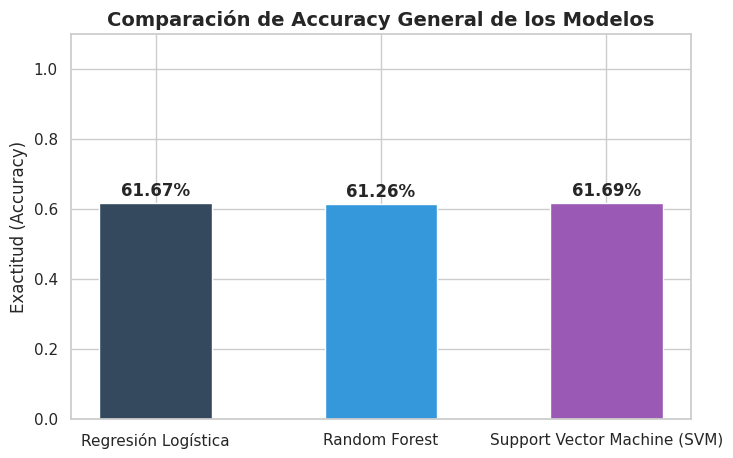

In [9]:
#EVALUACIÓN COMPARATIVA DE RENDIMIENTO

from sklearn.metrics import accuracy_score, classification_report

resultados_accuracy = {}

print("--- REPORTE DE CLASIFICACIÓN POR MODELO ---\n")
for nombre in modelos.keys():
    acc = accuracy_score(y_test, predicciones[nombre])
    resultados_accuracy[nombre] = acc
    print(f"=== {nombre} ===")
    print(f"Accuracy General: {acc:.4f}")
    print(classification_report(y_test, predicciones[nombre], target_names=['Fallado', 'Anotado']))
    print("-" * 50)

# Graficar la comparación de Accuracy
plt.figure(figsize=(8, 5))
colors = ['#34495e', '#3498db', '#9b59b6']
bars = plt.bar(resultados_accuracy.keys(), resultados_accuracy.values(), color=colors, width=0.5)

# Integrar etiquetas de porcentaje sobre las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval*100:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.title('Comparación de Accuracy General de los Modelos', fontsize=14, fontweight='bold')
plt.ylabel('Exactitud (Accuracy)', fontsize=12)
plt.ylim(0, 1.1)
plt.show()

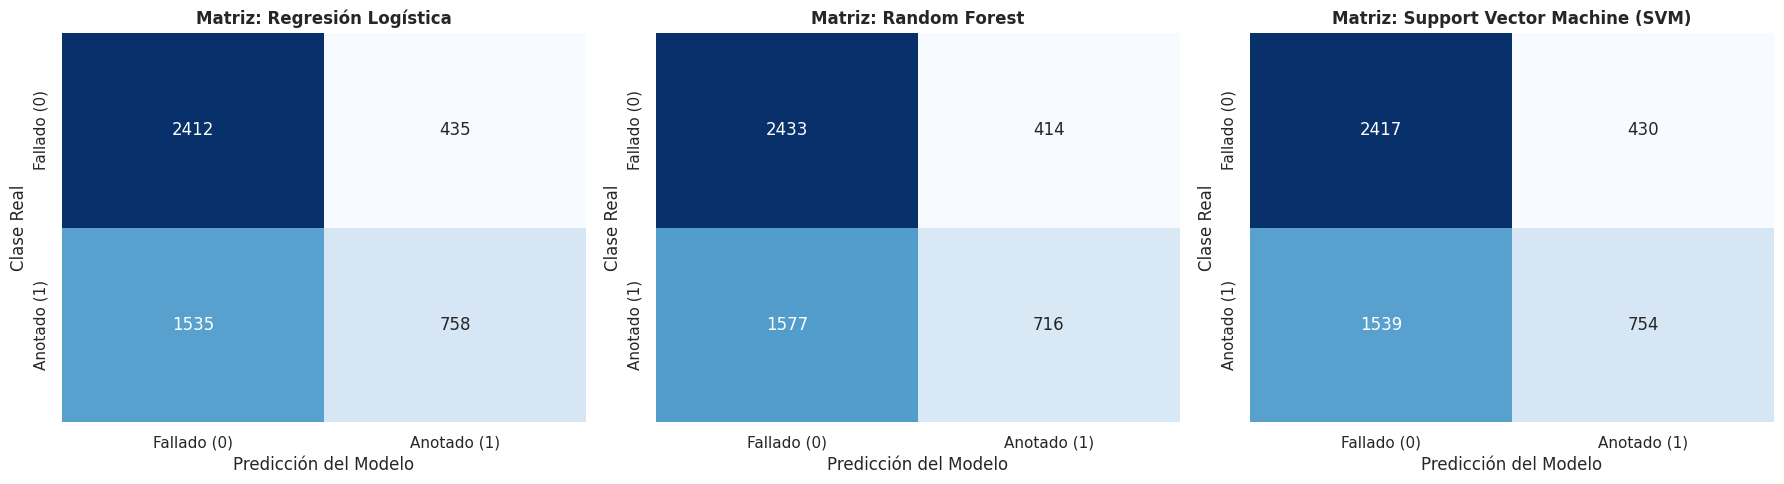

In [10]:
# MATRICES DE CONFUSIÓN COMPARADAS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (nombre, pred) in enumerate(predicciones.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Fallado (0)', 'Anotado (1)'],
                yticklabels=['Fallado (0)', 'Anotado (1)'])
    axes[i].set_title(f'Matriz: {nombre}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicción del Modelo')
    axes[i].set_ylabel('Clase Real')

plt.tight_layout()
plt.show()


## 7. Conclusiones
Este proyecto o trabajo final valida con éxito un flujo estructurado de minería de datos bajo los estándares de la **Ciencia 2.0**. Se demuestra que la geometría espacial del tiro (distancia al aro) combinada con el contexto temporal provee una señal estadística valiosa, aunque fuertemente limitada por la naturaleza impredecible del deporte. Todo el entorno queda disponible de forma pública y reproducible en la comunidad académica.

## 8. Referencias Bibliográficas

1. **Alamar, B.** (2013). *Sports Analytics: A Guide for Coaches, Managers, and Other Decision Makers*. Columbia University Press. (Fundamentos sobre la importancia de la analítica en la toma de decisiones en el baloncesto).
2. **Kaggle.** (2016). *Kobe Bryant Shot Selection: Evaluation and Dataset*. Recuperado de https://www.kaggle.com/c/kobe-bryant-shot-selection (Origen oficial de los datos geoespaciales y temporales utilizados).
3. **Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, É.** (2011). *Scikit-learn: Machine learning in Python*. Journal of Machine Learning Research, 12, 2825-2830. (Sustento científico de las herramientas de software utilizadas para Regresión Logística, Random Forest y SVM).
4. **Shea, S. M.** (2014). *Basketball Analytics: Objective and Efficient Strategies for Understanding How Teams Win*. Advanced Metrics LLC. (Estudios previos sobre cómo la distancia euclidiana y el tipo de jugada afectan el porcentaje de tiro efectivo).